In [1]:
from tables import CenterExperimentConfig, CenterExperimentResult
from pathlib import Path
import joblib
from models.models import HierarchicalPanelICA
from cs_experiments import create_center_stimulus
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


Connecting sshrinivasan@134.76.19.44:3306


In [2]:
CenterExperimentResult()

config_id,posterior_samples
11bfba502279bf3b14be154fa3399f85,=BLOB=
917c4a92c325d8faca6a7ac9199157a7,=BLOB=
bd811f57f7f26f9541089b7510dd09b6,=BLOB=
eda22d8bab34b6a123e4cede0bd3f982,=BLOB=
b5c29547c060bd98c8cc9a725addde72,=BLOB=
2cb4b3cedd6ae538a9e74397b9707e50,=BLOB=
fc44b9206d3df8d2a86a8d7981ad0443,=BLOB=
15e47633ea9882d4a61dc5844dc39399,=BLOB=
364a05fb661e9369dfa8d28c4e877318,=BLOB=
dea39cfa98f9dddf2f4369f9f9cd5fb3,=BLOB=


In [3]:
results = CenterExperimentConfig * CenterExperimentResult

In [4]:
results

config_id,seed random seed,g_dim dimensionality of G,n_draws_per_chain number of samples to draw per chain,n_chains number of chains,cores number of cores to use,n_burnin number of initial samples to discard,contrast_scale scale to multiply with the stimulus,x_sigma std of the noise in X,i_sigma std of the noise in I,"stimulus_type 0: -1 blank, nonnegative int represents the number of the latent whose RF would be the stimulus center",posterior_samples
11bfba502279bf3b14be154fa3399f85,42,340,1000,4,4,1000,1.0,0.1,0.1,171,=BLOB=
917c4a92c325d8faca6a7ac9199157a7,42,340,1000,4,4,1000,1.0,0.1,0.1,191,=BLOB=
bd811f57f7f26f9541089b7510dd09b6,42,340,1000,4,4,1000,1.0,0.1,0.1,182,=BLOB=
eda22d8bab34b6a123e4cede0bd3f982,42,340,1000,4,4,1000,1.0,0.1,0.1,163,=BLOB=
b5c29547c060bd98c8cc9a725addde72,42,340,1000,4,4,1000,1.0,0.1,0.1,165,=BLOB=
2cb4b3cedd6ae538a9e74397b9707e50,42,340,1000,4,4,1000,1.0,0.1,0.1,197,=BLOB=
fc44b9206d3df8d2a86a8d7981ad0443,42,340,1000,4,4,1000,1.0,0.1,0.1,172,=BLOB=
15e47633ea9882d4a61dc5844dc39399,42,340,1000,4,4,1000,1.0,0.1,0.1,198,=BLOB=
364a05fb661e9369dfa8d28c4e877318,42,340,1000,4,4,1000,1.0,0.1,0.1,181,=BLOB=
dea39cfa98f9dddf2f4369f9f9cd5fb3,42,340,1000,4,4,1000,1.0,0.1,0.1,185,=BLOB=


In [5]:
data_basepath = Path("/src/project/data/ica/repeat_9_crop_12_comp_40")
G_X_model_path = data_basepath / f"layer3_models/layer3_340.joblib"
print("Loading G_X_model")
G_X_model = joblib.load(G_X_model_path)
print("G_X_model", G_X_model)

print("Loading X_I_models")
X_I_models_path = data_basepath / "layer2_models"
X_I_models = []
for entry in X_I_models_path.iterdir():
    # go through files and load joblib files
    if entry.is_file() and entry.suffix == ".joblib":
        model = joblib.load(entry)
        X_I_models.append(model)

print("Creating hierarchical model")
hmodel = HierarchicalPanelICA(
    G_X_model=G_X_model,
    X_sigma=0.1,
    X_I_models=X_I_models,
    I_sigma=0.1,
)

Loading G_X_model
G_X_model FastICA(n_components=340, random_state=42, whiten='unit-variance')
Loading X_I_models
Creating hierarchical model


{'config_id': '11bfba502279bf3b14be154fa3399f85', 'seed': 42, 'g_dim': 340, 'n_draws_per_chain': 1000, 'n_chains': 4, 'cores': 4, 'n_burnin': 1000, 'contrast_scale': 1.0, 'x_sigma': 0.1, 'i_sigma': 0.1, 'stimulus_type': 171, 'posterior_samples': '11bfba502279bf3b14be154fa3399f85.pkl'}


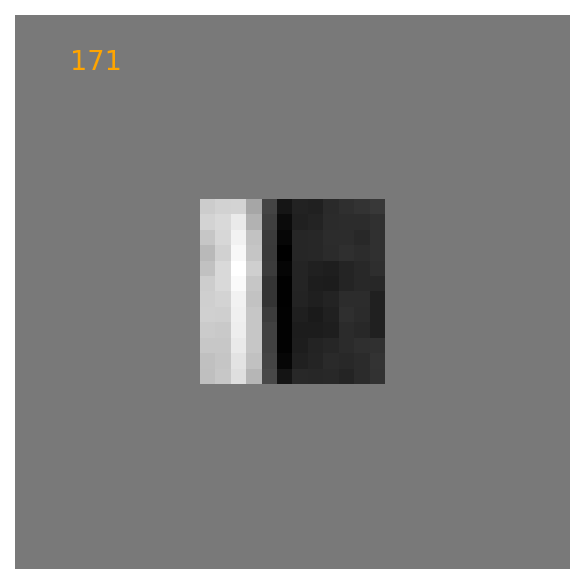

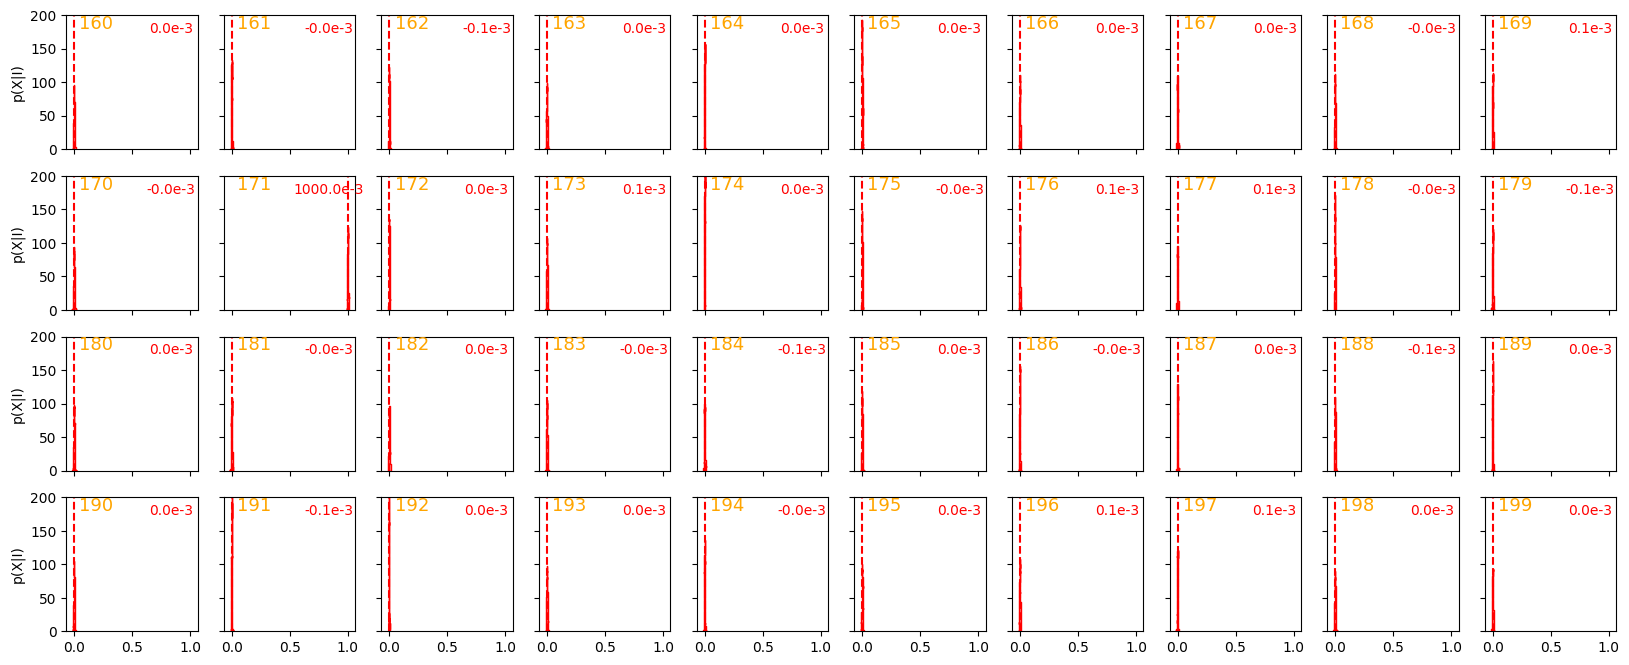

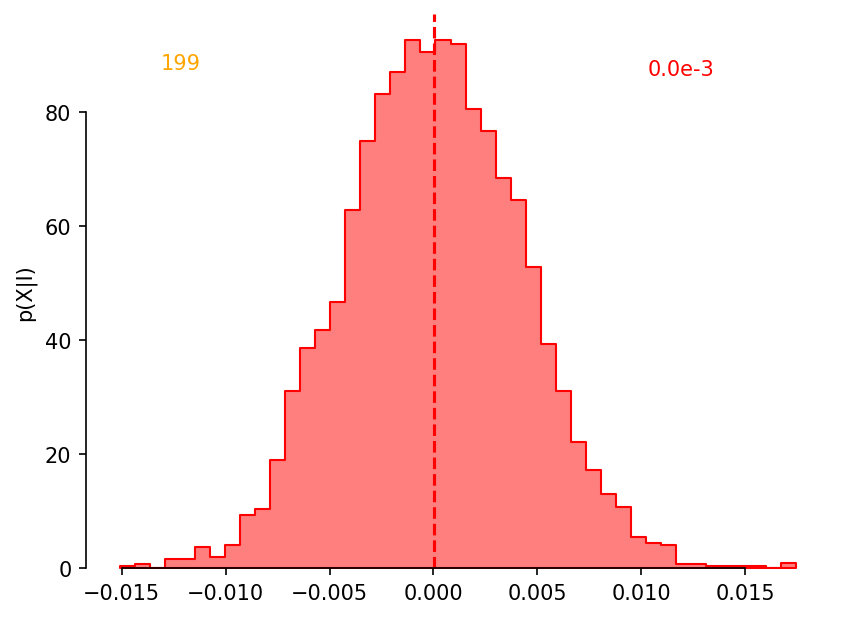

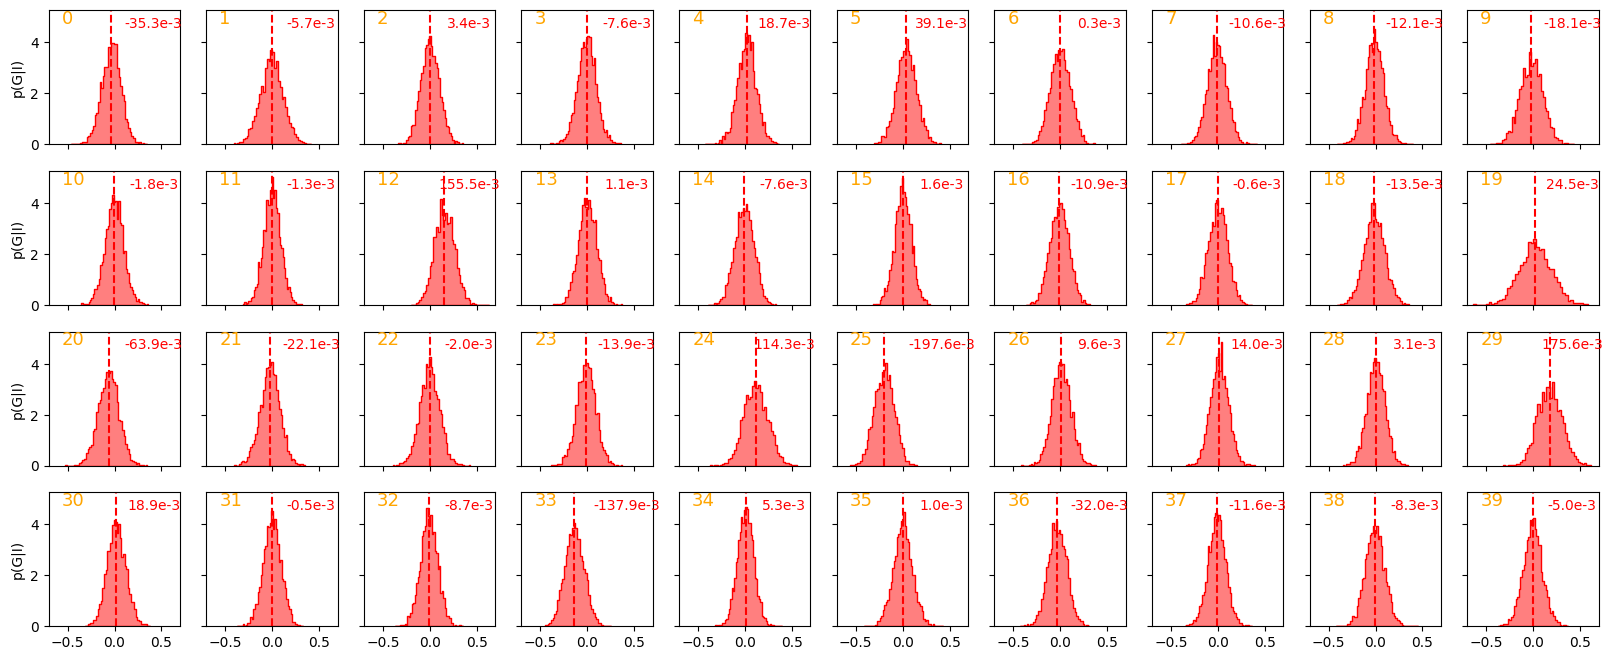

In [7]:
for row in results:
    print(row)
    stimulus = create_center_stimulus(
        hmodel, 
        row['stimulus_type'],
        row['contrast_scale'],
    )
    fig, ax = plt.subplots(dpi=150)
    ax.imshow(stimulus, cmap='gray')
    ax.text(
        0.1,
        0.9,
        str(row['stimulus_type']),
        color="orange",
        fontsize=13,
        transform=ax.transAxes,
    )
    ax.axis('off')
    fig.savefig(f"RF_center_stimulus_{row['stimulus_type']}.png", bbox_inches='tight')    
    chains = row["n_chains"]
    n_draws_per_chain = row["n_draws_per_chain"]
    X_dim = hmodel.X_dim
    samples_path = row["posterior_samples"]
    with open(samples_path, "rb") as f:
        idata = pickle.load(f)
    samples = idata['posterior']['X'].data.reshape(chains * n_draws_per_chain, X_dim)
    samples_mean = samples.mean(axis=0)

    g_samples = idata['posterior']['G'].data.reshape(chains * n_draws_per_chain, row['g_dim'])
    g_samples_mean = g_samples.mean(axis=0)

    center_offset = 160
    fig, axs = plt.subplots(nrows=4, ncols=10, figsize=(2*10, 2*4), sharex=True, sharey=True)
    for i, ax in enumerate(axs.flat):
        neuron_id = i + center_offset
        sns.histplot(
            samples[:, neuron_id],
            ax=ax,
            stat="density",
            color="red",
            element="step",
            alpha=0.5,
        )
        ax.axvline(samples_mean[neuron_id], color="red", linestyle="--")
        ax.text(0.8, 0.9, f"{samples_mean[neuron_id]*1000:.1f}e-3", size=10, ha="center", va="center", transform=ax.transAxes, color='red')
        ax.text(
            0.1,
            0.9,
            str(neuron_id),
            color="orange",
            fontsize=13,
            transform=ax.transAxes,
        )
        ax.set_ylim([0, 200])
        ax.set_ylabel("p(X|I)")
        # sns.despine(ax=ax, trim=True)
    fig.savefig(f"RF_center_posterior_{row['stimulus_type']}.png", bbox_inches='tight')
    fig, ax = plt.subplots(dpi=150)
    sns.histplot(
        samples[:, neuron_id],
        ax=ax,
        stat="density",
        color="red",
        element="step",
        alpha=0.5,
    )
    ax.axvline(samples_mean[neuron_id], color="red", linestyle="--")
    ax.text(0.8, 0.9, f"{samples_mean[neuron_id]*1000:.1f}e-3", size=10, ha="center", va="center", transform=ax.transAxes, color='red')
    ax.text(
        0.1,
        0.9,
        str(neuron_id),
        color="orange",
        # fontsize=13,
        transform=ax.transAxes,
    )
    # ax.set_ylim([0, 200])
    ax.set_ylabel("p(X|I)")
    sns.despine(ax=ax, trim=True)
    fig.savefig(f"RF_center_posterior_{row['stimulus_type']}_neuron_{row['stimulus_type']}.png", bbox_inches='tight')

    fig, axs = plt.subplots(nrows=4, ncols=10, figsize=(2*10, 2*4), sharex=True, sharey=True)
    for i, ax in enumerate(axs.flat):
        sns.histplot(
            g_samples[:, i],
            ax=ax,
            stat="density",
            color="red",
            element="step",
            alpha=0.5,
        )
        ax.axvline(g_samples_mean[i], color="red", linestyle="--")
        ax.text(0.8, 0.9, f"{g_samples_mean[i]*1000:.1f}e-3", size=10, ha="center", va="center", transform=ax.transAxes, color='red')
        ax.text(
            0.1,
            0.9,
            str(i),
            color="orange",
            fontsize=13,
            transform=ax.transAxes,
        )
        # ax.set_ylim([0, 200])
        ax.set_ylabel("p(G|I)")    
    fig.savefig(f"RF_center_posterior_{row['stimulus_type']}_g.png", bbox_inches='tight')